In [ ]:
#Class counts

import os
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = "../data/Covid19-dataset"
CLASSES = ["Covid", "Normal", "Viral Pneumonia"]

counts = {}
for split in ["train", "test"]:
    counts[split] = {}
    print(f"\n{split.upper()}")
    for cls in CLASSES:
        folder = os.path.join(DATA_DIR, split, cls)
        n = len(os.listdir(folder))
        counts[split][cls] = n
        print(f"  {cls}: {n} images")


TRAIN
  Covid: 111 images
  Normal: 70 images
  Viral Pneumonia: 70 images

TEST
  Covid: 26 images
  Normal: 20 images
  Viral Pneumonia: 20 images


In [ ]:
#checking for bad files
bad_files = []
for split in ["train", "test"]:
    for cls in CLASSES:
        folder = os.path.join(DATA_DIR, split, cls)
        for fname in os.listdir(folder):
            path = os.path.join(folder, fname)
            try:
                img = Image.open(path)
                img.verify()
            except Exception as e:
                bad_files.append((path, str(e)))

print(f"Corrupt/unreadable files: {len(bad_files)}")
for f in bad_files:
    print(f)

Corrupt/unreadable files: 0


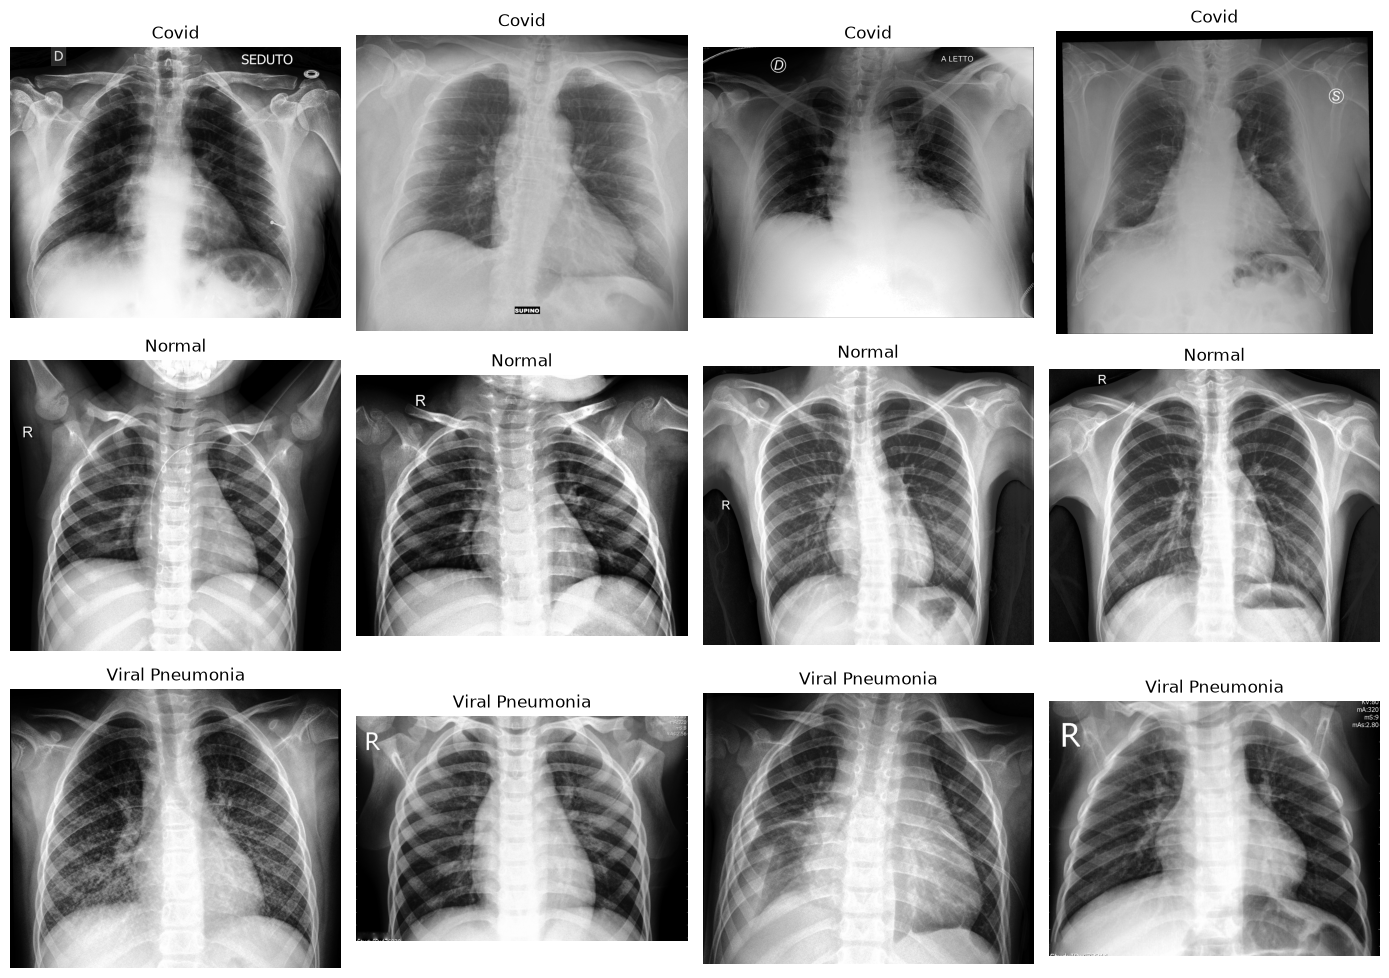

In [3]:
# Visualizing sample images from each class to sanity-check the data
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for row, cls in enumerate(CLASSES):
    folder = os.path.join(DATA_DIR, "train", cls)
    files = os.listdir(folder)[:4]
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

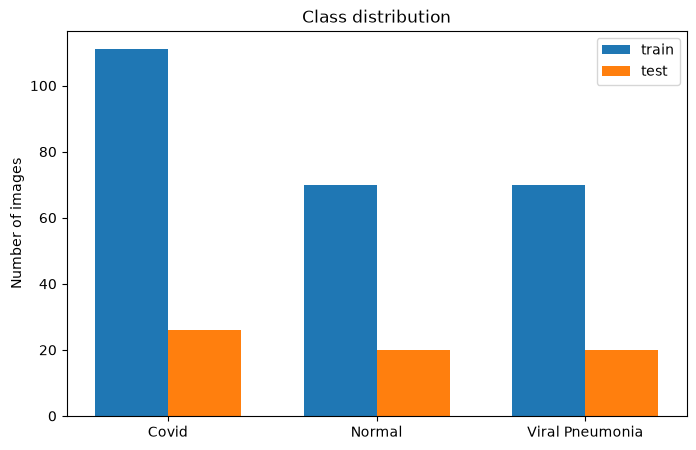

In [4]:
# Plotting class distribution as a bar chart to visualize imbalance
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(CLASSES))
width = 0.35

train_vals = [counts["train"][c] for c in CLASSES]
test_vals = [counts["test"][c] for c in CLASSES]

ax.bar(x - width/2, train_vals, width, label="train")
ax.bar(x + width/2, test_vals, width, label="test")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylabel("Number of images")
ax.set_title("Class distribution")
ax.legend()
plt.show()

In [5]:
# Checking image size consistency to see if resizing is needed
sizes = set()
for split in ["train", "test"]:
    for cls in CLASSES:
        folder = os.path.join(DATA_DIR, split, cls)
        for fname in os.listdir(folder)[:20]:
            img = Image.open(os.path.join(folder, fname))
            sizes.add(img.size)
print("Unique image sizes found (sample):", sizes)

Unique image sizes found (sample): {(651, 659), (2352, 2166), (1410, 720), (1208, 640), (1200, 944), (2297, 2032), (1708, 1710), (1456, 1080), (2746, 2382), (1206, 871), (1216, 936), (1816, 1435), (1727, 1442), (1024, 842), (1160, 776), (2026, 1412), (1210, 859), (1344, 1152), (1256, 856), (1884, 1447), (2061, 1369), (1742, 1372), (1670, 1319), (1624, 968), (2031, 1837), (1827, 1641), (1352, 1064), (880, 891), (882, 888), (1844, 1504), (1206, 875), (1742, 1392), (1336, 1024), (1224, 856), (1928, 1756), (1280, 872), (1272, 813), (2115, 1792), (2498, 2057), (1432, 1024), (1754, 1377), (439, 362), (1936, 1554), (1024, 1024), (1222, 878), (882, 876), (2000, 1456), (1294, 1022), (2216, 1953), (1118, 1333), (790, 631), (1192, 992), (2165, 1907), (1782, 1434), (1304, 968), (1280, 760), (416, 341), (2624, 1893), (1796, 1372), (1624, 1104), (2271, 1827), (2720, 2458), (2059, 1483), (2022, 2071), (1488, 1136), (2494, 2048), (2024, 1836), (1224, 1008), (1458, 1303), (4200, 3408), (880, 874), (189